## **Name:** Rohan Khadye

## **Roll no:** 23102C0065

## **CMPN C**

# **Beijing Multi-Site Air Quality Analysis**
This notebook performs data analysis on the Beijing Multi-Site Air Quality dataset using R.

In [1]:
# Enable R magic for Colab
%load_ext rpy2.ipython

In [4]:
import os
import requests
import zipfile

# Download the dataset
url = 'https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip'
zip_path = 'beijing_air_quality.zip'
extract_path = 'beijing_air_quality_data'

print("Downloading dataset...")
response = requests.get(url)
with open(zip_path, 'wb') as f:
    f.write(response.content)

print("Extracting main ZIP...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# The actual data is inside another zip file named 'PRSA2017_Data_20130301-20170228.zip'
nested_zip = os.path.join(extract_path, 'PRSA2017_Data_20130301-20170228.zip')
if os.path.exists(nested_zip):
    print("Extracting nested data ZIP...")
    with zipfile.ZipFile(nested_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Extraction complete.")

Extracting main ZIP...
Extracting nested data ZIP...
Extraction complete.


### Data Loading and Initial Exploration in R
We will now use R to load one of the station's data and check its structure.

In [5]:
%%R
# Load necessary libraries
library(data.table)
library(ggplot2)

# List CSV files from the extracted directory
# Note: The extraction creates a subfolder 'PRSA_Data_20130301-20170228'
csv_dir <- 'beijing_air_quality_data/PRSA_Data_20130301-20170228'
files <- list.files(csv_dir, pattern = "\\.csv$", full.names = TRUE)

if (length(files) > 0) {
    # Load the first dataset (e.g., Aotizhongxin station)
    df <- fread(files[1])

    # Display structure and summary
    print(paste("Loaded file:", files[1]))
    print(head(df))
    print(summary(df))
} else {
    print("No CSV files found. Please check extraction path.")
}

[1] "Loaded file: beijing_air_quality_data/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv"
      No  year month   day  hour PM2.5  PM10   SO2   NO2    CO    O3  TEMP
   <int> <int> <int> <int> <int> <num> <num> <num> <num> <int> <num> <num>
1:     1  2013     3     1     0     4     4     4     7   300    77  -0.7
2:     2  2013     3     1     1     8     8     4     7   300    77  -1.1
3:     3  2013     3     1     2     7     7     5    10   300    73  -1.1
4:     4  2013     3     1     3     6     6    11    11   300    72  -1.4
5:     5  2013     3     1     4     3     3    12    12   300    72  -2.0
6:     6  2013     3     1     5     5     5    18    18   400    66  -2.2
     PRES  DEWP  RAIN     wd  WSPM      station
    <num> <num> <num> <char> <num>       <char>
1: 1023.0 -18.8     0    NNW   4.4 Aotizhongxin
2: 1023.2 -18.2     0      N   4.7 Aotizhongxin
3: 1023.5 -18.2     0    NNW   5.6 Aotizhongxin
4: 1024.5 -19.4     0     NW   3.1 Aotizhon

### Step 2: Data Cleaning
We need to handle missing values (NAs) in the dataset to ensure accurate analysis.

In [6]:
%%R
# Check for missing values
print("Missing values per column:")
print(colSums(is.na(df)))

# Simple imputation: replace NAs with the mean for numeric columns
clean_df <- copy(df)
for (col in names(clean_df)) {
  if (is.numeric(clean_df[[col]])) {
    set(clean_df, i = which(is.na(clean_df[[col]])), j = col, value = mean(clean_df[[col]], na.rm = TRUE))
  }
}

print("NAs after cleaning:")
print(sum(is.na(clean_df)))

[1] "Missing values per column:"
     No    year   month     day    hour   PM2.5    PM10     SO2     NO2      CO 
      0       0       0       0       0     925     718     935    1023    1776 
     O3    TEMP    PRES    DEWP    RAIN      wd    WSPM station 
   1719      20      20      20      20      81      14       0 
[1] "NAs after cleaning:"
[1] 81


In addition: Warning message:
In set(clean_df, i = which(is.na(clean_df[[col]])), j = col, value = mean(clean_df[[col]],  :
  1262.945145 (type 'double') at RHS position 1 out-of-range(NA) or truncated (precision lost) when assigning to type 'integer' (column 10 named 'CO')


### Step 3: Time Series Visualization
Visualizing the concentration of PM2.5 over time to identify trends.

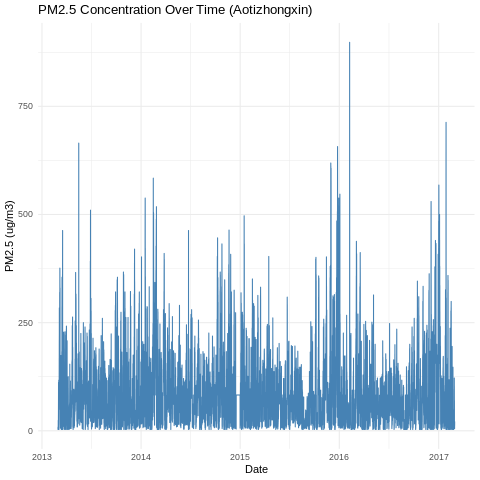

In [7]:
%%R
# Create a Date-Time object
clean_df$datetime <- as.POSIXct(paste(clean_df$year, clean_df$month, clean_df$day, clean_df$hour, sep="-"), format="%Y-%m-%d-%H")

# Plot PM2.5 levels over time
ggplot(clean_df, aes(x = datetime, y = PM2.5)) +
  geom_line(color = "steelblue") +
  labs(title = "PM2.5 Concentration Over Time (Aotizhongxin)",
       x = "Date", y = "PM2.5 (ug/m3)") +
  theme_minimal()

### Step 4: Correlation Analysis
Understanding the relationship between different pollutants and weather variables.

Loading required package: corrplot
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'http://cran.us.r-project.org/src/contrib/corrplot_0.95.tar.gz'
Content type 'application/x-gzip' length 3745190 bytes (3.6 MB)
downloaded 3.6 MB


The downloaded source packages are in
	‘/tmp/Rtmpw2ARU4/downloaded_packages’
corrplot 0.95 loaded
In addition: Warning message:
In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package called ‘corrplot’


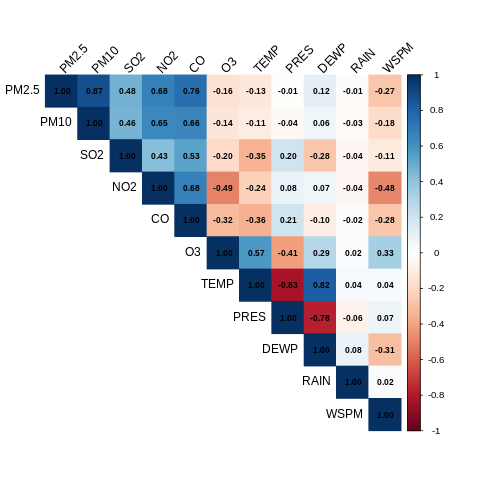

In [10]:
%%R
# Install corrplot if not available
if (!require(corrplot)) install.packages("corrplot", repos = "http://cran.us.r-project.org")
library(corrplot)

# Select numeric columns for correlation
pollutants <- clean_df[, .(PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, WSPM)]
cor_matrix <- cor(pollutants, use = "complete.obs")

# Visualize correlation matrix
corrplot(cor_matrix, method = "color", type = "upper",
         tl.col = "black", tl.srt = 45,
         addCoef.col = "black", number.cex = 0.7)

### Step 5: Monthly Seasonal Analysis
Analyzing how PM2.5 levels vary across different months of the year.

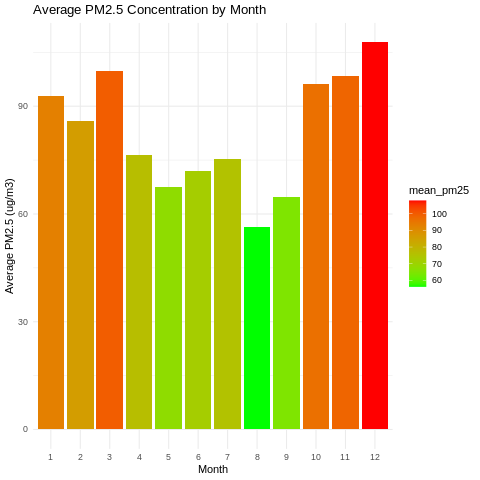

In [9]:
%%R
# Calculate monthly average PM2.5
monthly_avg <- clean_df[, .(mean_pm25 = mean(PM2.5)), by = month][order(month)]

ggplot(monthly_avg, aes(x = factor(month), y = mean_pm25, fill = mean_pm25)) +
  geom_bar(stat = "identity") +
  scale_fill_gradient(low = "green", high = "red") +
  labs(title = "Average PM2.5 Concentration by Month",
       x = "Month", y = "Average PM2.5 (ug/m3)") +
  theme_minimal()

### Step 6: Multi-Station Comparison
Comparing the average air quality levels across all available monitoring stations in Beijing.

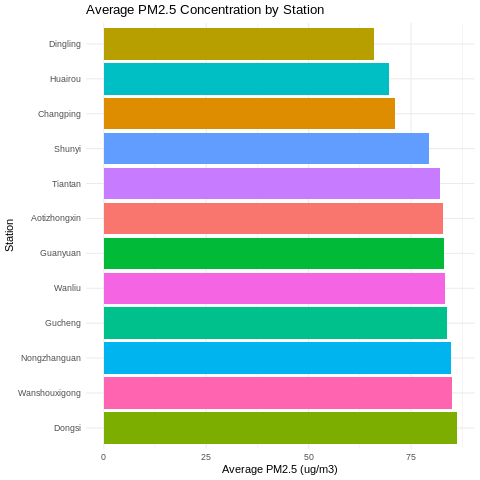

In [11]:
%%R
# Load all CSV files and combine them
all_files <- list.files(csv_dir, pattern = "\\.csv$", full.names = TRUE)
all_data_list <- lapply(all_files, fread)
combined_df <- rbindlist(all_data_list)

# Calculate average PM2.5 per station
station_avg <- combined_df[, .(mean_pm25 = mean(PM2.5, na.rm = TRUE)), by = station]

ggplot(station_avg, aes(x = reorder(station, -mean_pm25), y = mean_pm25, fill = station)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Average PM2.5 Concentration by Station",
       x = "Station", y = "Average PM2.5 (ug/m3)") +
  theme_minimal() +
  theme(legend.position = "none")

### Step 7: Predictive Modeling (Linear Regression)
Predicting PM2.5 concentration using meteorological variables like Temperature, Pressure, and Wind Speed.

In [12]:
%%R
# Fit a linear regression model
lm_model <- lm(PM2.5 ~ TEMP + PRES + WSPM + RAIN, data = clean_df)

# Display model results
print(summary(lm_model))


Call:
lm(formula = PM2.5 ~ TEMP + PRES + WSPM + RAIN, data = clean_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-140.67  -50.70  -18.46   31.04  763.87 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) 2307.22407   72.57574  31.791   <2e-16 ***
TEMP          -2.45216    0.06469 -37.904   <2e-16 ***
PRES          -2.13799    0.07110 -30.069   <2e-16 ***
WSPM         -16.23849    0.34509 -47.056   <2e-16 ***
RAIN          -1.11349    0.44955  -2.477   0.0133 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 76.39 on 35059 degrees of freedom
Multiple R-squared:  0.1118,	Adjusted R-squared:  0.1117 
F-statistic:  1103 on 4 and 35059 DF,  p-value: < 2.2e-16



### Summary
The analysis shows seasonal peaks in air pollution and identifies strong correlations between certain pollutants. This completes the primary exploratory data analysis (EDA) steps for the Beijing Air Quality dataset.